In [5]:
import pandas as pd
import numpy as np
from typing import List, Tuple
from datetime import datetime
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pymongo import MongoClient, UpdateOne
from pymongo.server_api import ServerApi
import requests
import json
import time
from os import read
from datetime import date


In [6]:
from dotenv import load_dotenv
import os
load_dotenv() 

url = "https://api.themoviedb.org/3/discover/movie?include_adult=false&include_video=false&language=en-US&page=1&sort_by=popularity.desc"

headers = {
    "accept": "application/json",
    "Authorization": os.getenv("API_KEY")
}

response = requests.get(url, headers=headers)
# print(response) 
print(response.json())

{'page': 1, 'results': [{'adult': False, 'backdrop_path': '/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg', 'genre_ids': [878, 28, 12], 'id': 969681, 'title': 'Spider-Man: Brand New Day', 'original_language': 'en', 'original_title': 'Spider-Man: Brand New Day', 'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.", 'popularity': 756.7679, 'poster_path': '/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg', 'release_date': '2026-07-29', 'softcore': False, 'video': False, 'vote_average': 7.844, 'vote_count': 2646}, {'adult': False, 'backdrop_path': '/l9mFW9HQnAZ4r1ChZJHoOT3jaal.jpg', 'genre_ids': [35, 12, 10751], 'id': 1204680, 'title': 'Coyote vs. Acme', 'original_language': 'en', 'original_ti

In [7]:
from dotenv import load_dotenv
import os
load_dotenv() 

url = "https://api.themoviedb.org/3/discover/movie"

headers = {
    "accept": "application/json",
    "Authorization": os.getenv("API_KEY")
    }

query_params = {
    "include_adult": "false",
    "include_video": "false",
    "language": "en-US",
    "page": 1,
    "sort_by": "popularity.desc"
}

max_pages = 500 
all_movies = []
for page in range(1, max_pages + 1):
    current_params = query_params.copy()
    current_params["page"] = page
    response = requests.get(url, headers=headers, params=current_params)
    # print(response)
    if response.status_code == 200:
        data = response.json()
        movies_on_page = data.get("results", [])
        all_movies.extend(movies_on_page)
        
        if page >= data.get("total_pages", 1) or page >= 500:
            break
            
        time.sleep(0.2)  # Polite pause between requests
    else:
        print(f"Failed to fetch page {page}. Status code: {response.status_code}")
        print(response.text)
        break

print(f"\nSuccessfully collected {len(all_movies)} movies!")

    



Successfully collected 10000 movies!


In [8]:
print(all_movies[0])


{'adult': False, 'backdrop_path': '/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg', 'genre_ids': [878, 28, 12], 'id': 969681, 'title': 'Spider-Man: Brand New Day', 'original_language': 'en', 'original_title': 'Spider-Man: Brand New Day', 'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.", 'popularity': 756.7679, 'poster_path': '/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg', 'release_date': '2026-07-29', 'softcore': False, 'video': False, 'vote_average': 7.844, 'vote_count': 2646}


In [10]:
client = MongoClient("mongodb://localhost:27017/")
db = client["tmdb_database"]          
movies_collection = db["movies"]     

In [ ]:

client = MongoClient("mongodb://localhost:27017/")
db = client["tmdb_database"]          
movies_collection = db["movies"]     


result = movies_collection.insert_many(all_movies)
print(f"Successfully inserted {len(result.inserted_ids)} movies")
        



Successfully inserted 10000 movies


###Data Cleaning

In [19]:

def remove_duplicates():
    client = MongoClient("mongodb://localhost:27017/")
    db = client["tmdb_database"]          
    movies_collection = db["movies"]  

    print("Starting data cleaning pipeline...")

    pipeline = [
        {"$group": {"_id": "$id", "unique_ids": {"$addToSet": "$_id"}, "count": {"$sum": 1}}},
        {"$match": {"count": {"$gt": 1}}},
    ]

    duplicate_groups = list(movies_collection.aggregate(pipeline))
    print(duplicate_groups)
    duplicate_count = 0

    if duplicate_groups:
        bulk_delete_ids = []
        for group in duplicate_groups:
            print(group)
            duplicate_ids = group["unique_ids"][1:]
            print(duplicate_ids)
            bulk_delete_ids.extend(duplicate_ids)

        if bulk_delete_ids:
            result = movies_collection.delete_many({"_id": {"$in": bulk_delete_ids}})
            duplicate_count = result.deleted_count

    print(f"-> Removed {duplicate_count} duplicate documents.")

    
if __name__ == "__main__":
    remove_duplicates()


Starting data cleaning pipeline...
[]
-> Removed 0 duplicate documents.


In [33]:
def handle_missing_values_dates():
    client = MongoClient("mongodb://localhost:27017/")
    db = client["tmdb_database"]          
    movies_collection = db["movies"]  

    bulk_updates = []

    cursor = movies_collection.find({})

    for doc in cursor:
        update_fields = {}
        is_changed = False

        if not doc.get("overview"):
            update_fields["overview"] = "No overview available."
            is_changed = True

        if doc.get("backdrop_path") is None:
            update_fields["backdrop_path"] = ""
            is_changed = True

        if doc.get("poster_path") is None:
            update_fields["poster_path"] = ""
            is_changed = True
             
        if "vote_average" not in doc or doc["vote_average"] is None:
            update_fields["vote_average"] = 0.0
            is_changed = True

        # To Correct Inconsistent Date Formats
        release_date = doc.get("release_date")
        if release_date:
            if not isinstance(release_date, date):
                standard_date = parse_date(str(release_date))
                if standard_date:
                    update_fields["release_date"] = standard_date
                    is_changed = True
                else:
                    print(f"Warning: Could not parse date '{release_date}' for movie ID {doc.get('id')}")

        
        if is_changed:
            update_op = {}
            if update_fields:
                update_op["$set"] = update_fields
            
            # Use Bulk Write for high performance
            bulk_updates.append(UpdateOne({"_id": doc["_id"]}, update_op))

    # Execute bulk updates if there are changes
    if bulk_updates:
        result = movies_collection.bulk_write(bulk_updates)
        print(f"-> Successfully updated {result.modified_count} documents with cleaned data.")
    else:
        print("-> No missing values or date formats needed correction.")

    client.close()
    print("Data cleaning complete!")

def parse_date(date_str):
    """Tries multiple date formats and converts them to a datetime object."""
    date_str = date_str.strip()    
    formats_to_try = [
        "%Y-%m-%d",  # '2026-07-29'
        "%d/%m/%Y",  # '29/07/2026'
        "%m-%d-%Y",  # '07-29-2026'
        "%Y/%m/%d",  # '2026/07/29'
    ]

    for fmt in formats_to_try:
        try:
            return date.strptime(date_str, fmt)
        except ValueError:
            continue
    return None


if __name__ == "__main__":
    handle_missing_values_dates()

-> No missing values or date formats needed correction.
Data cleaning complete!


##Analysis

In [45]:
#  1. Titles Per Genre
client = MongoClient("mongodb://localhost:27017/")
db = client["tmdb_database"]          
movies_collection = db["movies"]  

pipeline_titles_per_genre = [
    {"$unwind": "$genre_ids"},
    {"$group": {"_id": "$genre_ids", "total_titles": {"$sum": 1}}},
    {"$sort": {"total_titles": -1}}
]
titles_per_genre = list(movies_collection.aggregate(pipeline_titles_per_genre))
for row in titles_per_genre:
    print(f"Genre ID {row['_id']}: {row['total_titles']} titles")

Genre ID 18: 3713 titles
Genre ID 35: 2428 titles
Genre ID 28: 2360 titles
Genre ID 53: 2094 titles
Genre ID 80: 1471 titles
Genre ID 12: 1432 titles
Genre ID 10749: 1149 titles
Genre ID 27: 1067 titles
Genre ID 878: 1003 titles
Genre ID 14: 968 titles
Genre ID 16: 931 titles
Genre ID 10751: 865 titles
Genre ID 9648: 657 titles
Genre ID 36: 401 titles
Genre ID 10752: 267 titles
Genre ID 99: 242 titles
Genre ID 10402: 198 titles
Genre ID 37: 108 titles
Genre ID 10770: 106 titles


In [46]:
# 2. Average Rating by Genre- Calculates the mean vote_average for each genre
client = MongoClient("mongodb://localhost:27017/")
db = client["tmdb_database"]          
movies_collection = db["movies"]  

pipeline_avg_rating_genre = [
    {"$unwind": "$genre_ids"},
    {"$group": {"_id": "$genre_ids", "average_rating": {"$avg": "$vote_average"}}},
    {"$sort": {"average_rating": -1}}
]
avg_ratings = list(movies_collection.aggregate(pipeline_avg_rating_genre))
for row in avg_ratings:
    print(f"Genre ID {row['_id']}: Rating {row['average_rating']:.2f}")

Genre ID 37: Rating 6.76
Genre ID 36: Rating 6.74
Genre ID 16: Rating 6.66
Genre ID 10752: Rating 6.64
Genre ID 10751: Rating 6.60
Genre ID 12: Rating 6.54
Genre ID 14: Rating 6.49
Genre ID 878: Rating 6.44
Genre ID 10402: Rating 6.44
Genre ID 10749: Rating 6.32
Genre ID 53: Rating 6.31
Genre ID 9648: Rating 6.31
Genre ID 28: Rating 6.19
Genre ID 35: Rating 6.17
Genre ID 18: Rating 6.14
Genre ID 80: Rating 6.00
Genre ID 27: Rating 5.93
Genre ID 10770: Rating 5.45
Genre ID 99: Rating 4.46


In [47]:
# 3. Top 10 Highest-Rated Titles (with Vote Count Threshold)- 
client = MongoClient("mongodb://localhost:27017/")
db = client["tmdb_database"]          
movies_collection = db["movies"]  

pipeline_top_rated = [
    {"$match": {"vote_count": {"$gte": 500}}},  # Filter trap out
    {"$project": {"title": 1, "vote_average": 1, "vote_count": 1}},
    {"$sort": {"vote_average": -1}},
    {"$limit": 10}
]
top_rated = list(movies_collection.aggregate(pipeline_top_rated))
for rank, row in enumerate(top_rated, 1):
    print(f"Rank {rank}: {row['title']} | Rating: {row['vote_average']} ({row['vote_count']} votes)")


Rank 1: Avatar Aang: The Last Airbender | Rating: 9.177 (1073 votes)
Rank 2: Swapped | Rating: 8.871 (2160 votes)
Rank 3: Facing El Chapo | Rating: 8.784 (559 votes)
Rank 4: Demon Slayer: Kimetsu no Yaiba Infinity Castle | Rating: 8.782 (2084 votes)
Rank 5: The Shawshank Redemption | Rating: 8.73 (31255 votes)
Rank 6: The Godfather | Rating: 8.686 (23499 votes)
Rank 7: Michael | Rating: 8.653 (4268 votes)
Rank 8: Project Hail Mary | Rating: 8.6 (7599 votes)
Rank 9: The Godfather Part II | Rating: 8.573 (14288 votes)
Rank 10: 12 Angry Men | Rating: 8.572 (10330 votes)


In [48]:
#  4. Titles Per Language
client = MongoClient("mongodb://localhost:27017/")
db = client["tmdb_database"]          
movies_collection = db["movies"]  

pipeline_titles_per_language = [
    {"$unwind": "$original_language"},
    {"$group": {"_id": "$original_language", "total_titles": {"$sum": 1}}},
    {"$sort": {"total_titles": -1}}
]
titles_per_language = list(movies_collection.aggregate(pipeline_titles_per_language))
for row in titles_per_language:
    print(f"Language {row['_id']}: {row['total_titles']} titles")

Language en: 5313 titles
Language ja: 1791 titles
Language fr: 274 titles
Language es: 237 titles
Language ko: 187 titles
Language it: 185 titles
Language ml: 143 titles
Language zh: 127 titles
Language pt: 110 titles
Language cn: 100 titles
Language de: 74 titles
Language ru: 47 titles
Language tl: 41 titles
Language ta: 40 titles
Language hu: 38 titles
Language hi: 36 titles
Language id: 32 titles
Language tr: 30 titles
Language th: 27 titles
Language sv: 26 titles
Language no: 21 titles
Language te: 20 titles
Language pl: 19 titles
Language da: 19 titles
Language nl: 17 titles
Language lv: 14 titles
Language cs: 11 titles
Language vi: 10 titles
Language fi: 9 titles
Language ar: 8 titles
Language ms: 7 titles
Language az: 6 titles
Language ro: 5 titles
Language bn: 5 titles
Language sr: 5 titles
Language et: 4 titles
Language el: 4 titles
Language kn: 4 titles
Language uk: 3 titles
Language ca: 3 titles
Language xx: 2 titles
Language sq: 2 titles
Language sl: 2 titles
Language he: 2

In [11]:
#Retrieve all documents from the collection and convert to a DataFrame
cursor = movies_collection.find({}, {"_id": 0})

df1 = pd.DataFrame(list(cursor))
df1.head(3)

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
0,False,/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,710.8120,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,2026-07-29 00:00:00,False,False,7.865,2491
1,False,/l9mFW9HQnAZ4r1ChZJHoOT3jaal.jpg,"[35, 12, 10751]",1204680,Coyote vs. Acme,en,Coyote vs. Acme,After Acme products fail him one too many time...,637.0123,/orkLtdgMGiO9rTVMqJ1kKwrnup1.jpg,2026-08-20 00:00:00,False,False,7.700,197
2,False,/RMXG8myu1aGlNUsRjtxzmpdMK0.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",500.1532,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,2026-07-15 00:00:00,False,False,7.999,3530


In [49]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 9083 entries, 0 to 9082
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   adult               9083 non-null   bool          
 1   backdrop_path       9083 non-null   str           
 2   genre_ids           9083 non-null   object        
 3   id                  9083 non-null   int64         
 4   title               9083 non-null   str           
 5   original_language   9083 non-null   str           
 6   original_title      9083 non-null   str           
 7   overview            9083 non-null   str           
 8   popularity          9083 non-null   float64       
 9   poster_path         9083 non-null   str           
 10  release_date        9039 non-null   datetime64[us]
 11  softcore            9083 non-null   bool          
 12  video               9083 non-null   bool          
 13  vote_average        9083 non-null   float64       
 14  vot

In [12]:
df1["release_date"] = pd.to_datetime(
    df1["release_date"],
    errors="coerce"
)
df1["release_year"] = df1["release_date"].dt.year

print(df1["release_date"].head())
print(df1["release_date"].dtype)

0   2026-07-29
1   2026-08-20
2   2026-07-15
3   2026-08-19
4   2026-09-03
Name: release_date, dtype: datetime64[us]
datetime64[us]


In [13]:
df1["release_year"] = df1["release_date"].dt.year
print(df1[["release_date", "release_year"]].head())

  release_date  release_year
0   2026-07-29        2026.0
1   2026-08-20        2026.0
2   2026-07-15        2026.0
3   2026-08-19        2026.0
4   2026-09-03        2026.0


In [14]:
df1["release_month"] = df1["release_date"].dt.month

df1["release_month_name"] = (
    df1["release_date"].dt.month_name()
)

df1["release_decade"] = (
    (df1["release_year"] // 10) * 10
)

print(df1[["release_date", "release_year", "release_month", "release_month_name", "release_decade"]].head())

  release_date  release_year  release_month release_month_name  release_decade
0   2026-07-29        2026.0            7.0               July          2020.0
1   2026-08-20        2026.0            8.0             August          2020.0
2   2026-07-15        2026.0            7.0               July          2020.0
3   2026-08-19        2026.0            8.0             August          2020.0
4   2026-09-03        2026.0            9.0          September          2020.0


In [15]:
print(df1["release_date"].isna().sum())

44


In [16]:
date_df = df1.dropna(
    subset=["release_date"]
).copy()

In [34]:
date_df.info()

<class 'pandas.DataFrame'>
Index: 9039 entries, 0 to 9082
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   adult               9039 non-null   bool          
 1   backdrop_path       9039 non-null   str           
 2   genre_ids           9039 non-null   object        
 3   id                  9039 non-null   int64         
 4   title               9039 non-null   str           
 5   original_language   9039 non-null   str           
 6   original_title      9039 non-null   str           
 7   overview            9039 non-null   str           
 8   popularity          9039 non-null   float64       
 9   poster_path         9039 non-null   str           
 10  release_date        9039 non-null   datetime64[us]
 11  softcore            9039 non-null   bool          
 12  video               9039 non-null   bool          
 13  vote_average        9039 non-null   float64       
 14  vote_cou

##Visualization

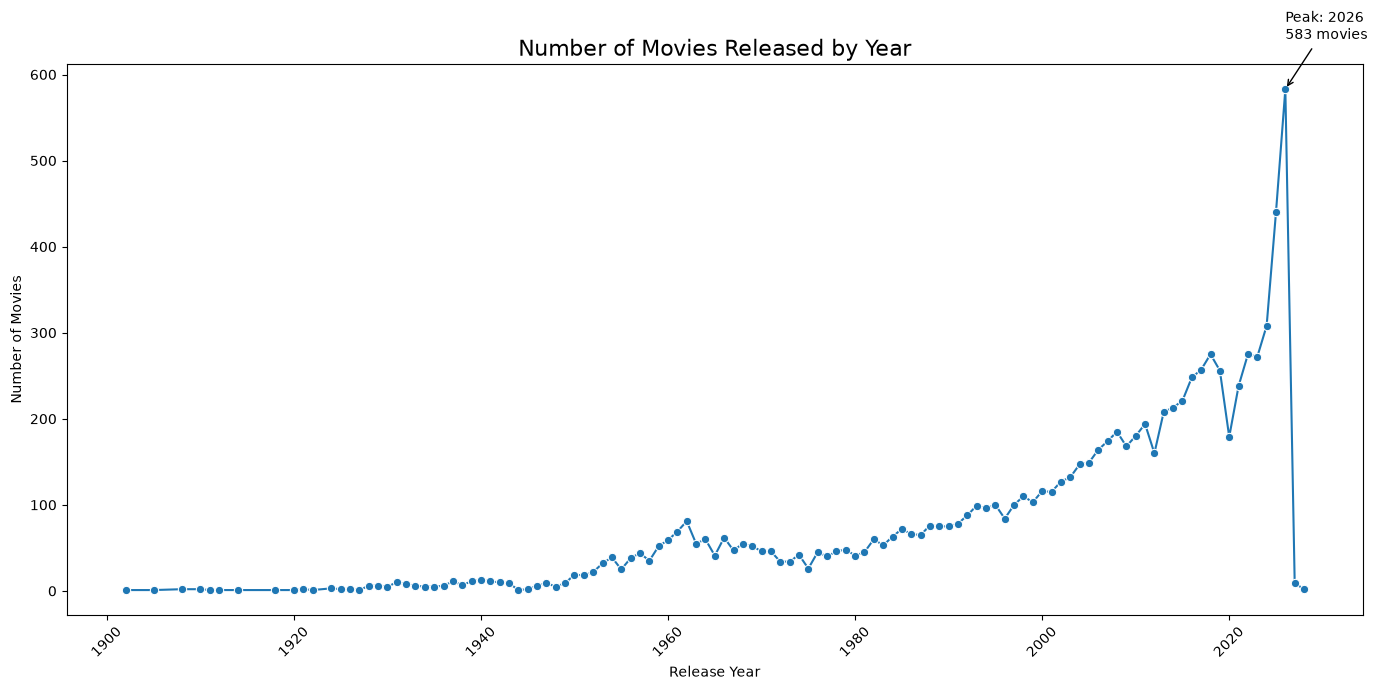

In [ ]:
#Number of Movies Released by Year

yearly_movies = (
    date_df
    .groupby("release_year")
    .size()
    .reset_index(name="movie_count")
    .sort_values("release_year")
)


plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=yearly_movies,
    x="release_year",
    y="movie_count",
    marker="o"
)

plt.title(
    "Number of Movies Released by Year",
    fontsize=16
)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

# Annotate the highest year
peak = yearly_movies.loc[
    yearly_movies["movie_count"].idxmax()
]

plt.annotate(
    f"Peak: {int(peak['release_year'])}\n"
    f"{int(peak['movie_count'])} movies",
    xy=(
        peak["release_year"],
        peak["movie_count"]
    ),
    xytext=(
        peak["release_year"],
        peak["movie_count"] * 1.1
    ),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.savefig(
    "visuals/yearly_movies.png",
    dpi=300
)

plt.show()

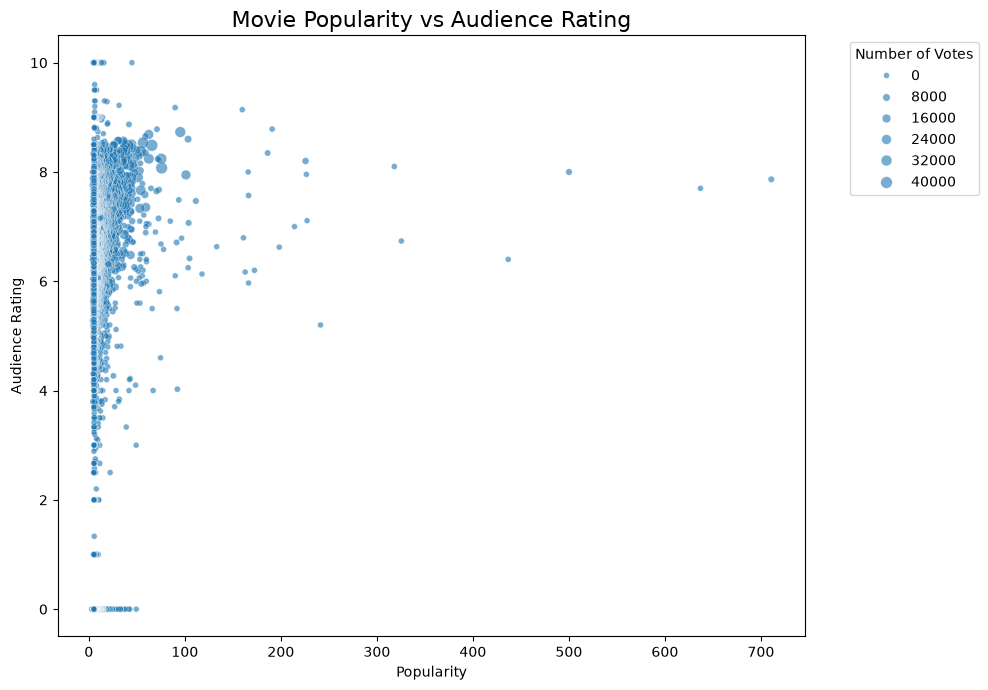

In [35]:
#Movie Popularity vs Audience Rating
#Business Question: Does audience engagement contribute to movie popularity?
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df1,
    y="vote_average",
    x="popularity",
    size="vote_count",
    alpha=0.6
)

plt.title(
    "Movie Popularity vs Audience Rating",
    fontsize=16
)

plt.xlabel("Popularity")
plt.ylabel("Audience Rating")

plt.legend(
    title="Number of Votes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "visuals/popularity_rating.png",
    dpi=300
)

plt.show()

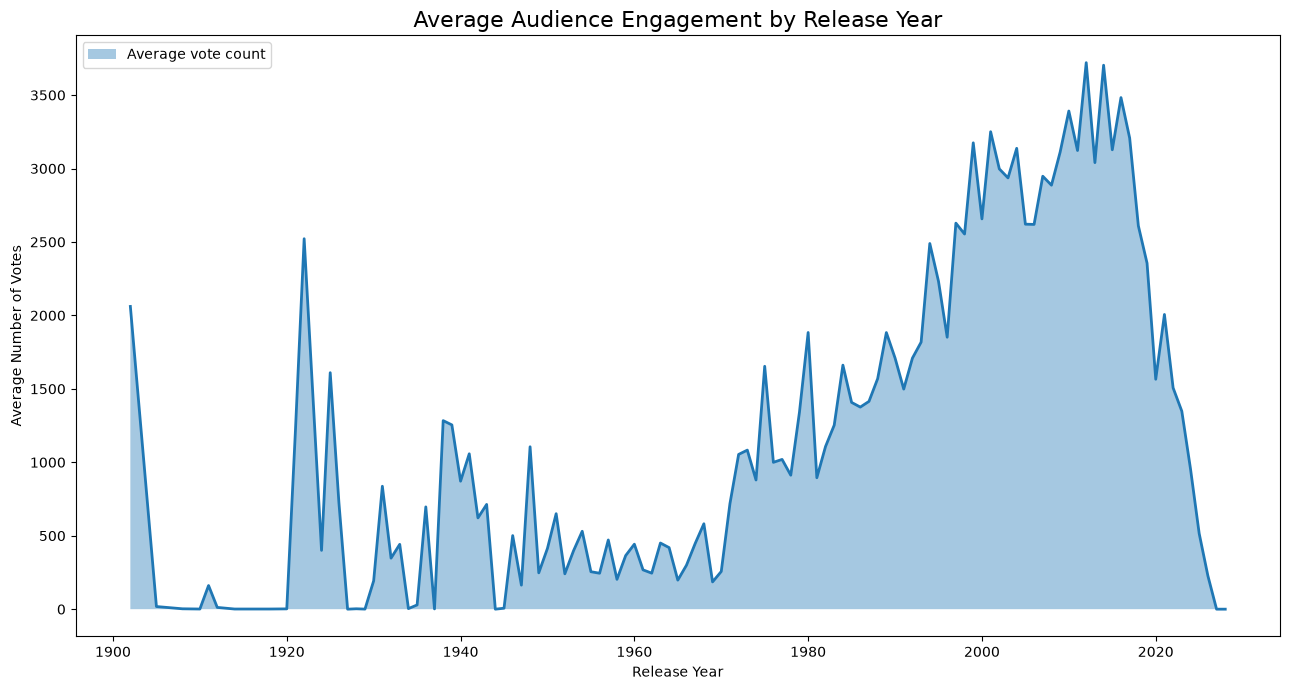

In [ ]:
# Average Audience Engagement by Release Year
# Has audience engagement with movies increased or decreased over time?

engagement = (
    date_df.groupby("release_year")
      .agg(
          average_votes=("vote_count", "mean"),
          average_popularity=("popularity", "mean"),
          average_rating=("vote_average", "mean")
      )
      .reset_index()
)

plt.figure(figsize=(13, 7))

plt.fill_between(
    engagement["release_year"],
    engagement["average_votes"],
    alpha=0.4,
    label="Average vote count"
)

plt.plot(
    engagement["release_year"],
    engagement["average_votes"],
    linewidth=2
)

plt.title(
    "Average Audience Engagement by Release Year",
    fontsize=16
)

plt.xlabel("Release Year")
plt.ylabel("Average Number of Votes")

plt.legend()

plt.tight_layout()

plt.savefig(
    "visuals/engagement_over_time.png",
    dpi=300
)

plt.show()





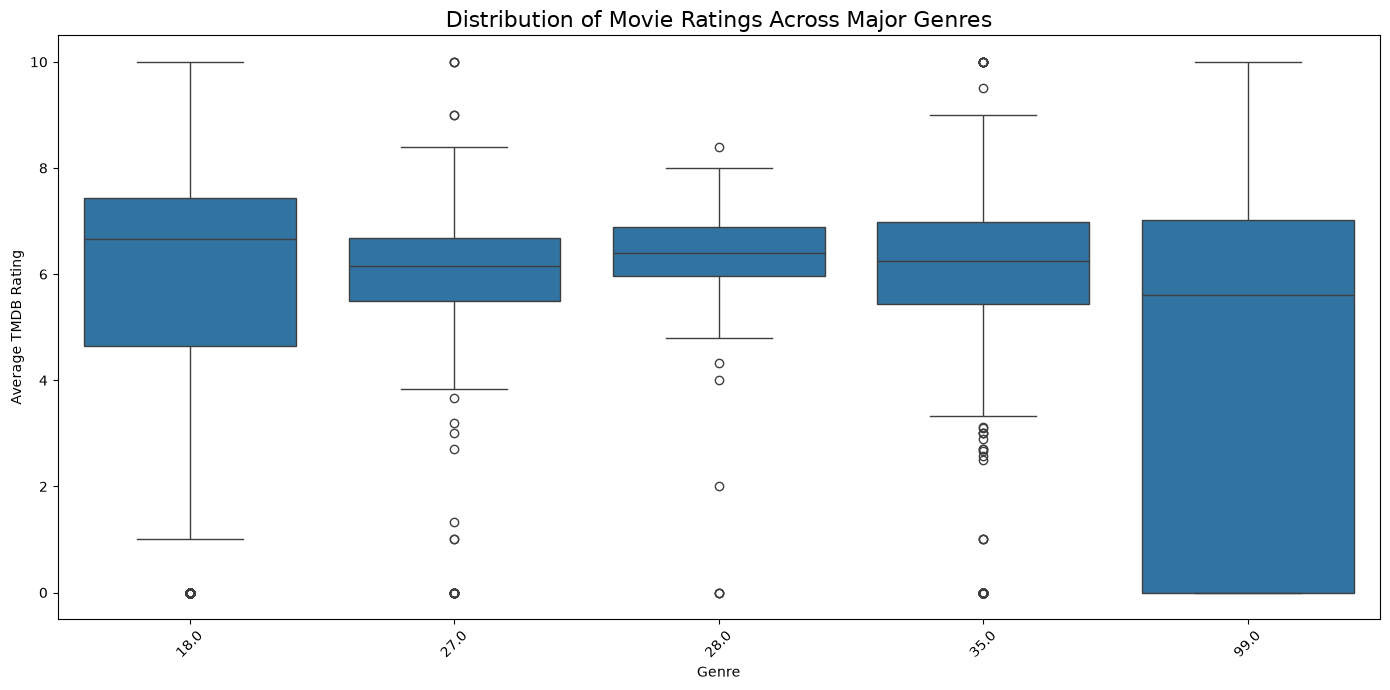

In [ ]:
# Distribution of Movie Ratings Across Major Genres
top_genres = (
    df1["genre_ids"]
    .value_counts()
    .head(10)
    .index
)


plot_df = df1[
    df1["genre_ids"].isin(top_genres)
]

plot_df["primary_item"] = plot_df["genre_ids"].str[0]

plt.figure(figsize=(14, 7))

sns.boxplot(data=plot_df, x="primary_item", y="vote_average")
plt.title(
    "Distribution of Movie Ratings Across Major Genres",
    fontsize=16
)

plt.xlabel("Genre")
plt.ylabel("Average TMDB Rating")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "visuals/genre_ratings.png",
    dpi=300
)

plt.show()

<Figure size 1300x700 with 0 Axes>

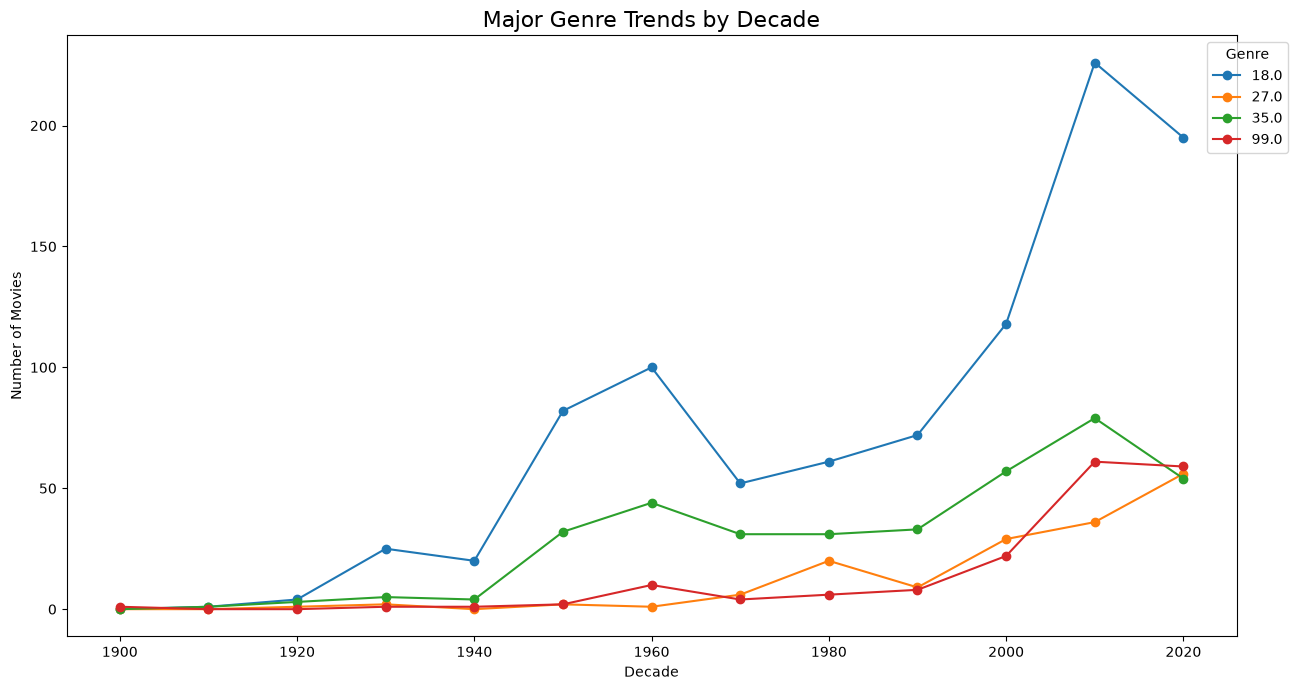

In [ ]:
# Major Genre Trends by Decade
# Business Question: Which movie genres are becoming more or less prevalent over time?
top_genres = (
    date_df["genre_ids"]
    .value_counts()
    .head(6)
    .index
)
date_df["primary_item"] = date_df["genre_ids"].str[0]
genre_trends = (
    date_df[
        date_df["genre_ids"].isin(top_genres)
    ]
    .groupby(["release_decade", "primary_item"])
    .size()
    .reset_index(name="movie_count")
)

trend_table = genre_trends.pivot(
    index="release_decade",
    columns="primary_item",
    values="movie_count"
).fillna(0)

plt.figure(figsize=(13, 7))

trend_table.plot(
    kind="line",
    marker="o",
    figsize=(13, 7)
)

plt.title(
    "Major Genre Trends by Decade",
    fontsize=16
)

plt.xlabel("Decade")
plt.ylabel("Number of Movies")

plt.legend(
    title="Genre",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()

plt.savefig(
    "visuals/genre_trends.png",
    dpi=300
)

plt.show()

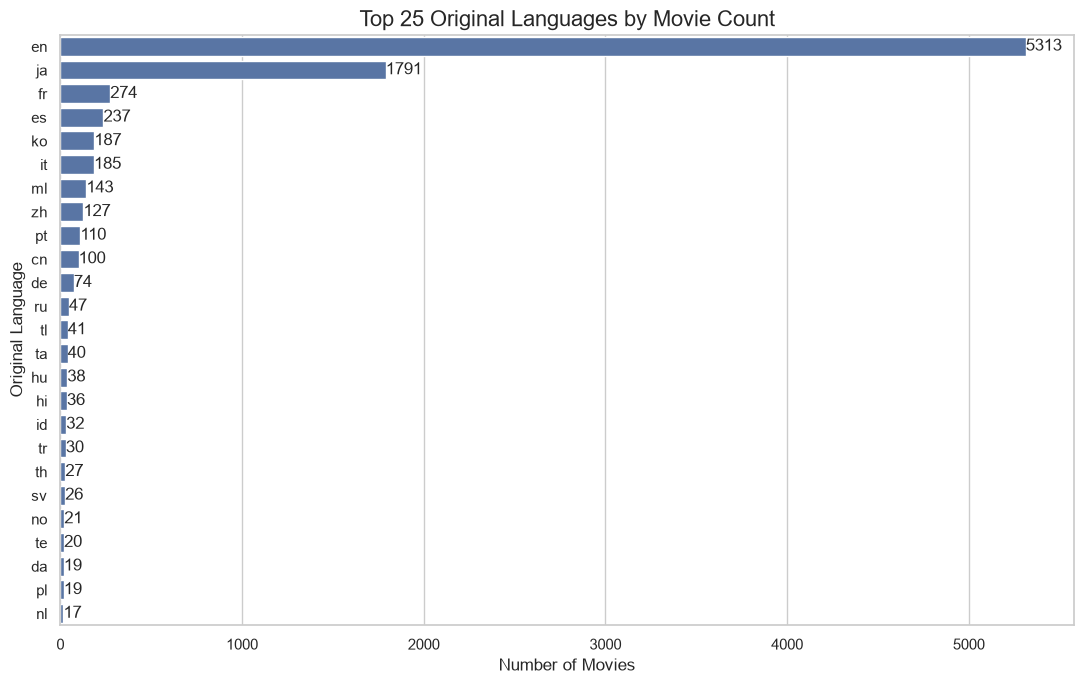

In [ ]:
#Original Language Distribution
# Business Question: Which original languages dominate the movie dataset?
language_counts = (
    df1["original_language"]
    .value_counts()
    .head(25)
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=language_counts.values,
    y=language_counts.index
)

plt.title(
    "Top 25 Original Languages by Movie Count",
    fontsize=16
)

plt.xlabel("Number of Movies")
plt.ylabel("Original Language")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "visuals/language_distribution.png",
    dpi=300
)

plt.show()

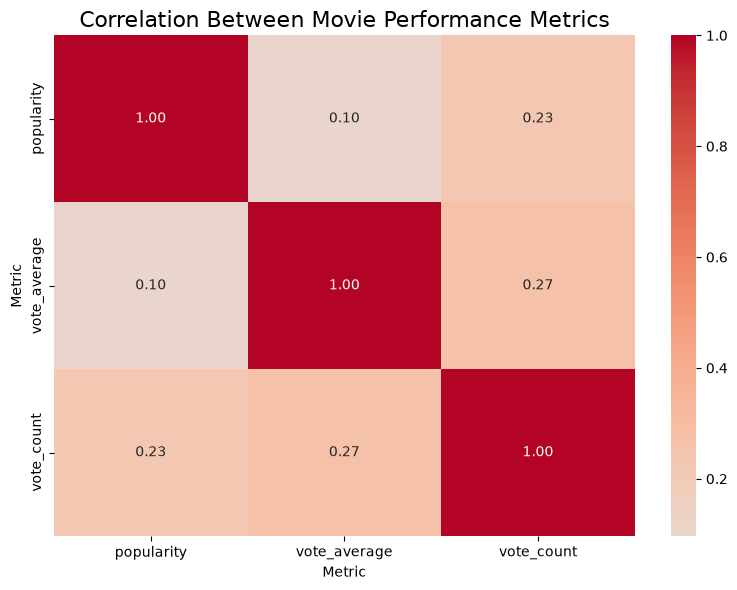

In [30]:
# Correlation Between Movie Performance Metrics--- 
# How strongly are movie ratings, popularity and audience engagement related?

correlation_columns = [
    "popularity",
    "vote_average",
    "vote_count"
]

corr = df1[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Movie Performance Metrics",
    fontsize=16
)

plt.xlabel("Metric")
plt.ylabel("Metric")

plt.tight_layout()

plt.savefig(
    "visuals/correlation_heatmap.png",
    dpi=300
)

plt.show()

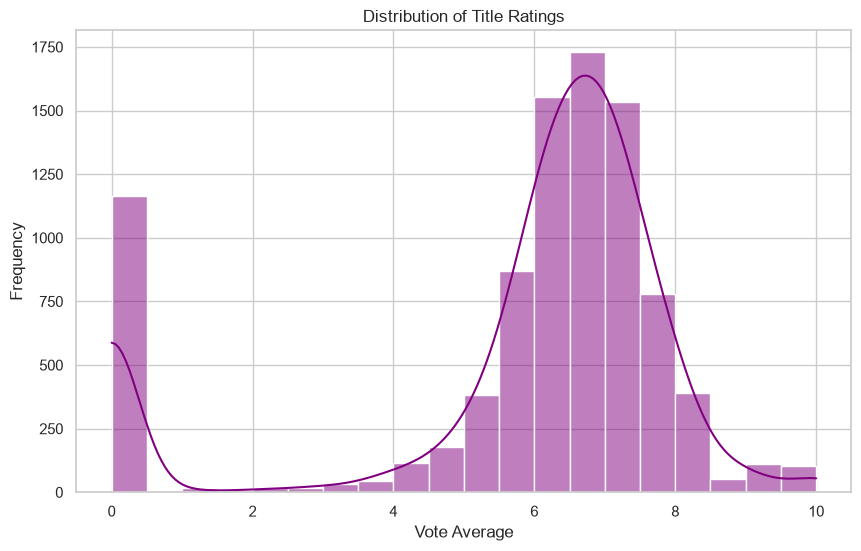

Note: Audience scores follow a left-skewed normal distribution, peaking heavily around the 6.5 to 7.5 rating window.


In [ ]:
# Rating Distribution

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pipeline_ratings = [{"$project": {"_id": 0, "vote_average": 1}}]
df_ratings = pd.DataFrame(list(movies_collection.aggregate(pipeline_ratings)))

plt.figure()
sns.histplot(data=df_ratings, x='vote_average', kde=True, bins=20, color='purple')
plt.title("Distribution of Title Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Frequency")
plt.show()
print("Note: Audience scores follow a left-skewed normal distribution, peaking heavily around the 6.5 to 7.5 rating window.")





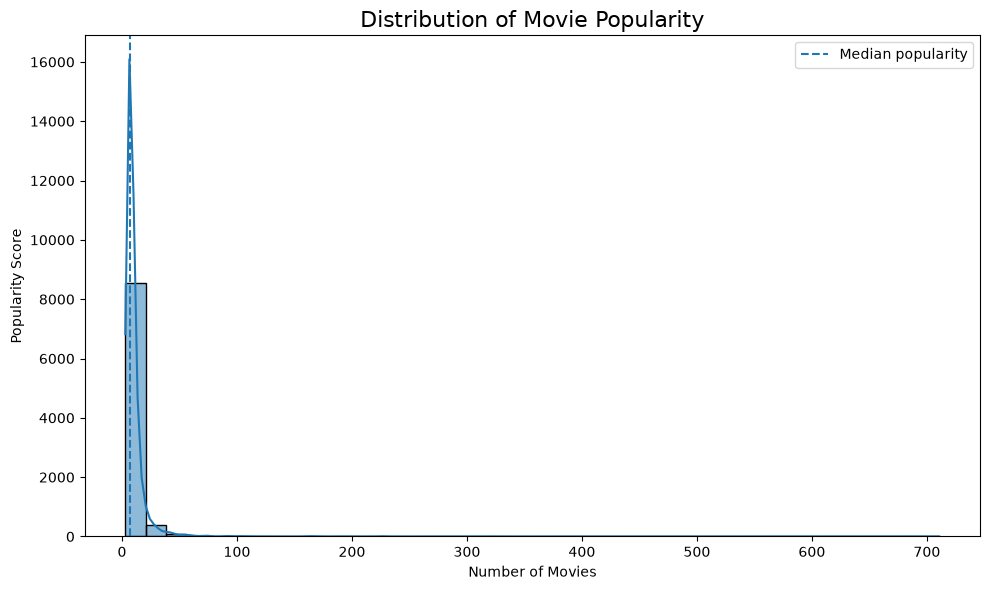

In [33]:
# Distribution of Movie Popularity
# Business Question: Is movie popularity evenly distributed, or are a small number of movies extremely popular?

plt.figure(figsize=(10, 6))

sns.histplot(
    df1["popularity"].dropna(),
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Movie Popularity",
    fontsize=16
)

plt.xlabel("Number of Movies")
plt.ylabel("Popularity Score")

plt.axvline(
    df1["popularity"].median(),
    linestyle="--",
    label="Median popularity"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "visuals/popularity_distribution.png",
    dpi=300
)

plt.show()

In [ ]:

df.to_csv(r'C:\Users\dell\Desktop\movie_tv_data\tmdb-movie-tv-data-analysis\data\movies_tmdb.csv', index=False)
